# Model Comparison - Test Set Evaluation (r=16)

Evaluation of all 7 trained models on the held-out PTB-XL test fold (fold 10).
Results use the improved PEFT configuration: **r=16, alpha=32, epochs=25, lr=1.5e-4**.

| Model | Type | Target modules | Params |
|---|---|---|---|
| FCN-Wang | baseline CNN | all | ~310 k (100%) |
| HeartBERT LoRA r=16 | RoBERTa + LoRA | q, v | ~1.5% of 125 M |
| HeartBERT DoRA r=16 | RoBERTa + DoRA | q, v | ~1.5% of 125 M |
| ECG-PT LoRA r=16 | GPT-2 + LoRA | c_attn | ~0.6% of 117 M |
| ECG-PT DoRA r=16 | GPT-2 + DoRA | c_attn | ~0.6% of 117 M |
| HuBERT-ECG LoRA r=16 | HuBERT + LoRA | q, k, v | ~2% of 93 M |
| HuBERT-ECG DoRA r=16 | HuBERT + DoRA | q, k, v | ~2% of 93 M |

Outputs saved to `results/05+_model_comparison/`.

In [1]:
import sys, os, warnings, json, gc
from pathlib import Path
sys.path.append('../')
os.environ['TRANSFORMERS_OFFLINE'] = '0'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import torch
import wfdb

from src.utils.config import CFG
from src.preprocessing.label_utils import load_all_labels, SUPERCLASSES

DATA_PATH    = CFG['data']['path']
RESULTS_PATH = CFG['paths']['results']
HUBERT_SIZE  = CFG['model']['hubert_size']
device       = 'cuda' if torch.cuda.is_available() else 'cpu'

OUT_DIR = Path(RESULTS_PATH) / '05+_model_comparison'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = [
    'fcn_wang_baseline',
    'heartbert_lora_r16',
    'heartbert_dora_r16',
    'ecgpt_lora_r16',
    'ecgpt_dora_r16',
    'hubert_ecg_lora_r16',
    'hubert_ecg_dora_r16',
]

MODEL_COLORS = {
    'fcn_wang_baseline':  '#7f7f7f',
    'heartbert_lora_r16':  '#1f77b4',
    'heartbert_dora_r16':  '#1f77b4',
    'ecgpt_lora_r16':      '#ff7f0e',
    'ecgpt_dora_r16':      '#ff7f0e',
    'hubert_ecg_lora_r16': '#2ca02c',
    'hubert_ecg_dora_r16': '#2ca02c',
}

all_results = {}

print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Output : {OUT_DIR}')

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
Output : D:\GitHub\biosignal-xai\results\05+_model_comparison


## 2. Data

Test fold = fold 10 (2 157 records, never seen during training).

- `X_test_lead` / `y_test`: single Lead II numpy arrays for HeartBERT and ECG-PT.
- `test_ds_full`: full 12-lead streaming dataset for HuBERT-ECG.

In [2]:
from src.preprocessing.dataset_full import ECGDatasetFull

Y = load_all_labels(
    DATA_PATH + 'ptbxl_database.csv',
    DATA_PATH + 'scp_statements.csv',
)
test_df = Y[Y.strat_fold == 10]

LEAD_IDX = 1  # Lead II

def _load_lead(df, data_path, lead_idx=LEAD_IDX):
    X, y = [], []
    for i, (_, row) in enumerate(df.iterrows()):
        sig, _ = wfdb.rdsamp(data_path + row['filename_lr'])
        X.append(sig[:, lead_idx].astype(np.float32))
        y.append(np.array(row['label_vec'], dtype=np.float32))
        if (i + 1) % 500 == 0:
            print(f'  {i+1}/{len(df)} records loaded...')
    return np.stack(X), np.stack(y)

print('Loading test set (single-lead)...')
X_test_lead, y_test = _load_lead(test_df, DATA_PATH)

test_ds_full = ECGDatasetFull(test_df, DATA_PATH)

assert X_test_lead.shape[1] == 1000, X_test_lead.shape
assert y_test.shape[1] == 5, y_test.shape

print(f'X_test_lead  : {X_test_lead.shape}')
print(f'y_test       : {y_test.shape}')
print(f'test_ds_full : {len(test_ds_full):,} records')

Records with valid labels: 21375
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5108 (23.9%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Loading test set (single-lead)...
  500/2157 records loaded...
  1000/2157 records loaded...
  1500/2157 records loaded...
  2000/2157 records loaded...
X_test_lead  : (2157, 1000)
y_test       : (2157, 5)
test_ds_full : 2,157 records


## 3. Evaluate models

FCN-Wang metrics are loaded from the JSON saved by notebook 03.
Each PEFT model is loaded, evaluated, then deleted to free GPU memory.

In [3]:
fcn_metrics = json.loads(
    (Path(RESULTS_PATH) / '03_preprocessing_pipeline' / 'metrics.json').read_text()
)
fcn_prof = json.loads(
    (Path(RESULTS_PATH) / 'fcn_wang_baseline' / 'profiling.json').read_text()
)

all_results['fcn_wang_baseline'] = {
    'auc_macro':          fcn_metrics['auc_macro'],
    'fmax':               fcn_metrics['fmax'],
    'auprc_macro':        fcn_metrics['auprc_macro'],
    'per_class_auc':      fcn_metrics['per_class_auc'],
    'auc_ci_95':          fcn_metrics.get('auc_ci_95', 'N/A'),
    'trainable_params':   fcn_prof['trainable_params'],
    'checkpoint_size_mb': fcn_prof['checkpoint_size_mb'],
}

assert abs(all_results['fcn_wang_baseline']['auc_macro'] - 0.9225) < 0.005, \
    f"Unexpected FCN-Wang AUC: {all_results['fcn_wang_baseline']['auc_macro']}"

print(f"FCN-Wang baseline: AUC {all_results['fcn_wang_baseline']['auc_macro']:.4f}")

FCN-Wang baseline: AUC 0.9225


In [4]:
from src.models.heartbert import HeartBERTClassifier
from src.evaluation.metrics import full_eval

EXP  = 'heartbert_lora_r16'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = HeartBERTClassifier(num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')

logits  = model.predict_logits(X_test_lead)
results = full_eval(logits, y_test, run_bootstrap=True, n_bootstrap=1000)

all_results[EXP] = {
    **results,
    'trainable_params':   prof['trainable_params'],
    'checkpoint_size_mb': prof['checkpoint_size_mb'],
}
print(f"{EXP}: AUC {results['auc_macro']:.4f}")

del model
gc.collect()
torch.cuda.empty_cache()

HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
heartbert_lora_r16: AUC 0.7761


In [5]:
from src.models.heartbert import HeartBERTClassifier
from src.evaluation.metrics import full_eval

EXP  = 'heartbert_dora_r16'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = HeartBERTClassifier(num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')

logits  = model.predict_logits(X_test_lead)
results = full_eval(logits, y_test, run_bootstrap=True, n_bootstrap=1000)

all_results[EXP] = {
    **results,
    'trainable_params':   prof['trainable_params'],
    'checkpoint_size_mb': prof['checkpoint_size_mb'],
}
print(f"{EXP}: AUC {results['auc_macro']:.4f}")

del model
gc.collect()
torch.cuda.empty_cache()

HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
heartbert_dora_r16: AUC 0.7622


In [6]:
from src.models.ecgpt import ECGPTClassifier
from src.evaluation.metrics import full_eval

EXP  = 'ecgpt_lora_r16'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = ECGPTClassifier(num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')

logits  = model.predict_logits(X_test_lead)
results = full_eval(logits, y_test, run_bootstrap=True, n_bootstrap=1000)

all_results[EXP] = {
    **results,
    'trainable_params':   prof['trainable_params'],
    'checkpoint_size_mb': prof['checkpoint_size_mb'],
}
print(f"{EXP}: AUC {results['auc_macro']:.4f}")

del model
gc.collect()
torch.cuda.empty_cache()

If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`).
  Falling back to gpt2 (GPT-2 architecture, general-language weights — NOT ECG-pretrained).
  To use the real ECG-PT weights, ensure the HF checkpoint is accessible (check your HF_TOKEN or the model visibility).


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
ecgpt_lora_r16: AUC 0.6181


In [7]:
from src.models.ecgpt import ECGPTClassifier
from src.evaluation.metrics import full_eval

EXP  = 'ecgpt_dora_r16'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = ECGPTClassifier(num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')

logits  = model.predict_logits(X_test_lead)
results = full_eval(logits, y_test, run_bootstrap=True, n_bootstrap=1000)

all_results[EXP] = {
    **results,
    'trainable_params':   prof['trainable_params'],
    'checkpoint_size_mb': prof['checkpoint_size_mb'],
}
print(f"{EXP}: AUC {results['auc_macro']:.4f}")

del model
gc.collect()
torch.cuda.empty_cache()

If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`).
  Falling back to gpt2 (GPT-2 architecture, general-language weights — NOT ECG-pretrained).
  To use the real ECG-PT weights, ensure the HF checkpoint is accessible (check your HF_TOKEN or the model visibility).


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
ecgpt_dora_r16: AUC 0.6187


In [8]:
from src.models.hubert_ecg import HuBERTECGClassifier
from src.evaluation.metrics import full_eval
from torch.utils.data import DataLoader

EXP  = 'hubert_ecg_lora_r16'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = HuBERTECGClassifier(size=HUBERT_SIZE, num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')
model.to(device)
model.eval()

test_loader = DataLoader(
    test_ds_full,
    batch_size  = 1,  # 1 record x 12 leads = 12 encoder runs; keeps OOM away
    shuffle     = False,
    num_workers = CFG['training']['num_workers'],
)

logits_list, labels_list = [], []
with torch.no_grad():
    for x, y in test_loader:
        logits_list.append(model(x.to(device)).cpu())
        labels_list.append(y)

logits  = torch.cat(logits_list).numpy()
labels  = torch.cat(labels_list).numpy()
results = full_eval(logits, labels, run_bootstrap=True, n_bootstrap=1000)

all_results[EXP] = {
    **results,
    'trainable_params':   prof['trainable_params'],
    'checkpoint_size_mb': prof['checkpoint_size_mb'],
}
print(f"{EXP}: AUC {results['auc_macro']:.4f}")

del model
gc.collect()
torch.cuda.empty_cache()

Loading HuBERT-ECG (base) from Edoardo-BS/hubert-ecg-base ...
  Done. Hidden dim: 768
hubert_ecg_lora_r16: AUC 0.6178


In [9]:
from src.models.hubert_ecg import HuBERTECGClassifier
from src.evaluation.metrics import full_eval
from torch.utils.data import DataLoader

EXP  = 'hubert_ecg_dora_r16'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = HuBERTECGClassifier(size=HUBERT_SIZE, num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')
model.to(device)
model.eval()

test_loader = DataLoader(
    test_ds_full,
    batch_size  = 1,  # 1 record x 12 leads = 12 encoder runs; keeps OOM away
    shuffle     = False,
    num_workers = CFG['training']['num_workers'],
)

logits_list, labels_list = [], []
with torch.no_grad():
    for x, y in test_loader:
        logits_list.append(model(x.to(device)).cpu())
        labels_list.append(y)

logits  = torch.cat(logits_list).numpy()
labels  = torch.cat(labels_list).numpy()
results = full_eval(logits, labels, run_bootstrap=True, n_bootstrap=1000)

all_results[EXP] = {
    **results,
    'trainable_params':   prof['trainable_params'],
    'checkpoint_size_mb': prof['checkpoint_size_mb'],
}
print(f"{EXP}: AUC {results['auc_macro']:.4f}")

del model
gc.collect()
torch.cuda.empty_cache()

Loading HuBERT-ECG (base) from Edoardo-BS/hubert-ecg-base ...
  Done. Hidden dim: 768
hubert_ecg_dora_r16: AUC 0.4261


## 4. Results table and plots

In [10]:
print(f"{'Model':<28}  {'Test AUC':>9}  {'95% CI':<24}  {'Fmax':>7}  {'AUPRC':>7}  {'Params':>12}  {'Ckpt':>7}")
print('-' * 100)
for exp in EXPERIMENTS:
    if exp not in all_results:
        print(f"{exp:<28}  (not evaluated)")
        continue
    res    = all_results[exp]
    params = res.get('trainable_params', 0)
    ckpt   = res.get('checkpoint_size_mb', 0.0)
    ci     = res.get('auc_ci_95', 'N/A')
    print(
        f"{exp:<28}  {res['auc_macro']:>9.4f}  {ci:<24}  "
        f"{res['fmax']:>7.4f}  {res['auprc_macro']:>7.4f}  "
        f"{params:>12,}  {ckpt:>6.1f} MB"
    )

Model                          Test AUC  95% CI                       Fmax    AUPRC        Params     Ckpt
----------------------------------------------------------------------------------------------------
fcn_wang_baseline                0.9225  0.922 [0.920, 0.925]       0.7458   0.8163       309,765     1.3 MB
heartbert_lora_r16               0.7761  0.776 [0.762, 0.789]       0.5376   0.5552       889,349     3.6 MB
heartbert_dora_r16               0.7622  0.762 [0.749, 0.775]       0.5167   0.5334       898,565     3.6 MB
ecgpt_lora_r16                   0.6181  0.618 [0.604, 0.632]       0.4196   0.3773       593,664     2.4 MB
ecgpt_dora_r16                   0.6187  0.618 [0.605, 0.632]       0.4158   0.3821       621,312     2.5 MB
hubert_ecg_lora_r16              0.6178  0.618 [0.605, 0.630]       0.3989   0.3600       884,736     3.5 MB
hubert_ecg_dora_r16              0.4261  0.426 [0.415, 0.438]       0.3988   0.2365       912,384     3.7 MB


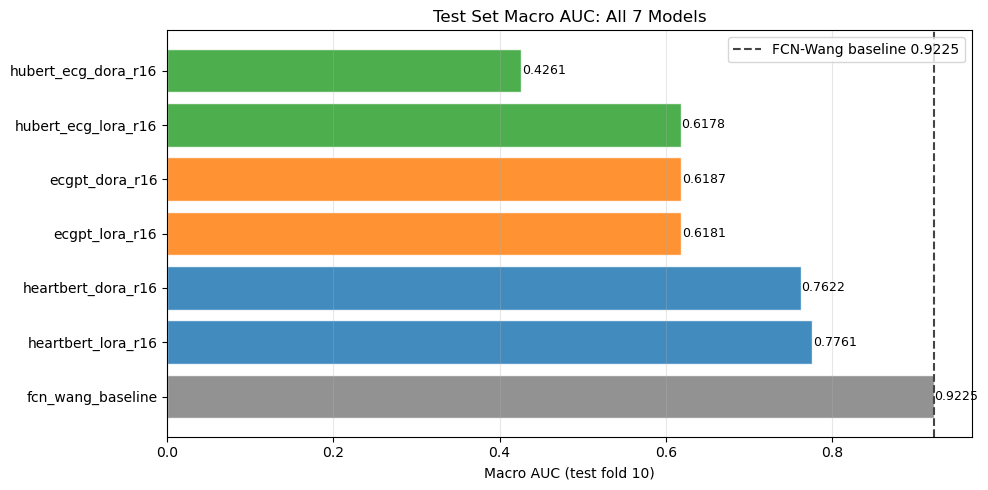

In [11]:
exp_order = [e for e in EXPERIMENTS if e in all_results]
aucs      = [all_results[e]['auc_macro'] for e in exp_order]
colors    = [MODEL_COLORS[e] for e in exp_order]

fig_auc, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(exp_order, aucs, color=colors, alpha=0.85, edgecolor='white')

fcn_auc = all_results['fcn_wang_baseline']['auc_macro']
ax.axvline(fcn_auc, color='#444', linestyle='--', linewidth=1.5,
           label=f'FCN-Wang baseline {fcn_auc:.4f}')

for bar, auc in zip(bars, aucs):
    ax.text(auc + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{auc:.4f}', va='center', fontsize=9)

ax.set_xlabel('Macro AUC (test fold 10)')
ax.set_title('Test Set Macro AUC: All 7 Models')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

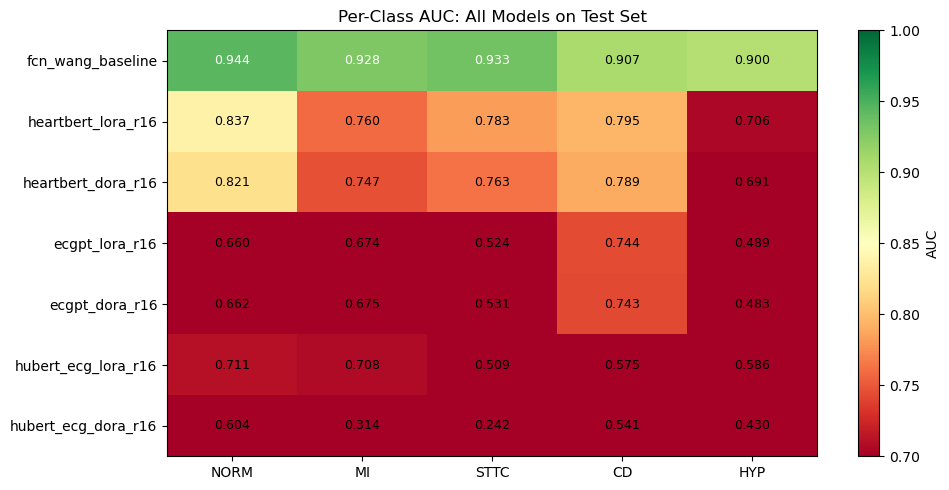

In [12]:
exp_order = [e for e in EXPERIMENTS if e in all_results]
data = np.array([
    [all_results[m]['per_class_auc'][sc] for sc in SUPERCLASSES]
    for m in exp_order
])

fig_heatmap, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(data, cmap='RdYlGn', vmin=0.7, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, label='AUC')

ax.set_xticks(range(len(SUPERCLASSES)))
ax.set_xticklabels(SUPERCLASSES)
ax.set_yticks(range(len(exp_order)))
ax.set_yticklabels(exp_order)

for i in range(len(exp_order)):
    for j in range(len(SUPERCLASSES)):
        ax.text(j, i, f'{data[i, j]:.3f}',
                ha='center', va='center', fontsize=9,
                color='black' if data[i, j] < 0.92 else 'white')

ax.set_title('Per-Class AUC: All Models on Test Set')
plt.tight_layout()
plt.show()

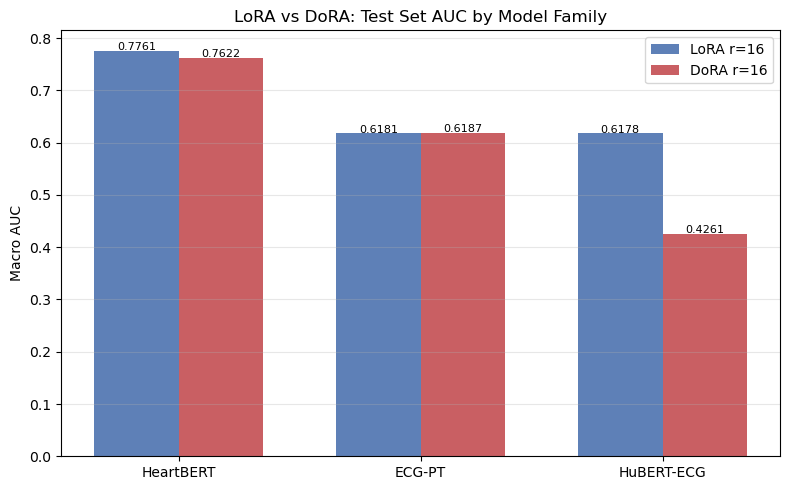

In [13]:
families    = ['heartbert', 'ecgpt', 'hubert_ecg']
fam_labels  = ['HeartBERT', 'ECG-PT', 'HuBERT-ECG']
lora_aucs   = [all_results.get(f'{f}_lora_r16', {}).get('auc_macro', 0) for f in families]
dora_aucs   = [all_results.get(f'{f}_dora_r16', {}).get('auc_macro', 0) for f in families]

x     = np.arange(len(families))
width = 0.35

fig_lora_dora, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width / 2, lora_aucs, width, label='LoRA r=16', color='#4c72b0', alpha=0.9)
bars2 = ax.bar(x + width / 2, dora_aucs, width, label='DoRA r=16', color='#c44e52', alpha=0.9)

for bar, v in zip(list(bars1) + list(bars2), lora_aucs + dora_aucs):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(fam_labels)
ax.set_ylabel('Macro AUC')
ax.set_title('LoRA vs DoRA: Test Set AUC by Model Family')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

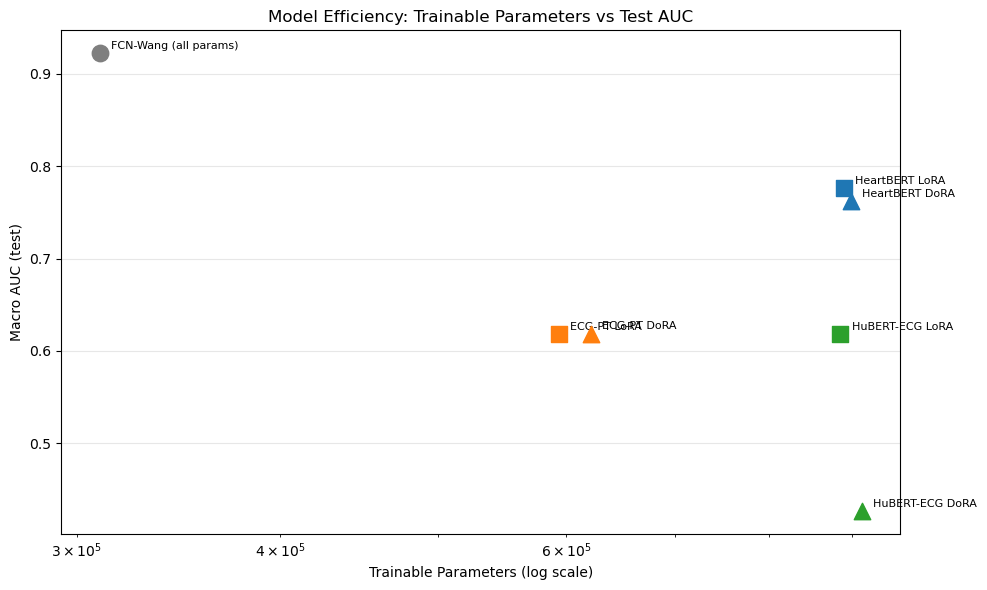

In [14]:
MARKERS = {
    'fcn_wang_baseline':  ('o', 'FCN-Wang (all params)'),
    'heartbert_lora_r16':  ('s', 'HeartBERT LoRA'),
    'heartbert_dora_r16':  ('^', 'HeartBERT DoRA'),
    'ecgpt_lora_r16':      ('s', 'ECG-PT LoRA'),
    'ecgpt_dora_r16':      ('^', 'ECG-PT DoRA'),
    'hubert_ecg_lora_r16': ('s', 'HuBERT-ECG LoRA'),
    'hubert_ecg_dora_r16': ('^', 'HuBERT-ECG DoRA'),
}

fig_efficiency, ax = plt.subplots(figsize=(10, 6))

for exp, res in all_results.items():
    params = res.get('trainable_params', 1)
    auc    = res['auc_macro']
    marker, label = MARKERS.get(exp, ('o', exp))
    ax.scatter(params, auc, c=MODEL_COLORS.get(exp, '#333'),
               marker=marker, s=140, zorder=5)
    ax.annotate(label, (params, auc),
                textcoords='offset points', xytext=(8, 3), fontsize=8)

ax.set_xscale('log')
ax.set_xlabel('Trainable Parameters (log scale)')
ax.set_ylabel('Macro AUC (test)')
ax.set_title('Model Efficiency: Trainable Parameters vs Test AUC')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
def _serialisable(obj):
    """Recursively convert numpy scalars to Python primitives."""
    if isinstance(obj, dict):
        return {k: _serialisable(v) for k, v in obj.items()}
    if isinstance(obj, (np.float32, np.float64, np.floating)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64, np.integer)):
        return int(obj)
    return obj

with open(OUT_DIR / 'all_metrics.json', 'w') as f:
    json.dump(_serialisable(all_results), f, indent=2)

fig_auc.savefig(FIG_DIR / 'auc_comparison.png',     dpi=150, bbox_inches='tight')
fig_heatmap.savefig(FIG_DIR / 'per_class_heatmap.png', dpi=150, bbox_inches='tight')
fig_lora_dora.savefig(FIG_DIR / 'lora_vs_dora.png',    dpi=150, bbox_inches='tight')
fig_efficiency.savefig(FIG_DIR / 'efficiency_scatter.png', dpi=150, bbox_inches='tight')

print('Saved:')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(Path(RESULTS_PATH))}  ({p.stat().st_size / 1024:.1f} KB)')

Saved:
  05+_model_comparison\all_metrics.json  (5.9 KB)
  05+_model_comparison\figures\auc_comparison.png  (67.9 KB)
  05+_model_comparison\figures\efficiency_scatter.png  (54.6 KB)
  05+_model_comparison\figures\lora_vs_dora.png  (42.0 KB)
  05+_model_comparison\figures\per_class_heatmap.png  (93.0 KB)


## 5. Report Table

Publication-ready summary table exported to `results/05+_model_comparison/`.

**Table 1** -- Classification performance on the held-out test fold (fold 10, n=2157).  
PEFT configuration: r=16, alpha=32, 32-bin ECG tokenisation (HeartBERT), q/k/v targets (HuBERT-ECG).

In [16]:
import pandas as pd

DISPLAY_NAMES = {
    'fcn_wang_baseline':  'FCN-Wang',
    'heartbert_lora_r16':  'HeartBERT LoRA r=16',
    'heartbert_dora_r16':  'HeartBERT DoRA r=16',
    'ecgpt_lora_r16':      'ECG-PT LoRA r=16',
    'ecgpt_dora_r16':      'ECG-PT DoRA r=16',
    'hubert_ecg_lora_r16': 'HuBERT-ECG LoRA r=16',
    'hubert_ecg_dora_r16': 'HuBERT-ECG DoRA r=16',
}

rows1 = []
for exp in EXPERIMENTS:
    if exp not in all_results:
        continue
    res = all_results[exp]
    row = {'Model': DISPLAY_NAMES[exp]}
    for sc in SUPERCLASSES:
        row[sc] = round(res['per_class_auc'].get(sc, float('nan')), 4)
    row['Macro AUC']       = round(res['auc_macro'], 4)
    row['Fmax']            = round(res.get('fmax', float('nan')), 4)
    row['AUPRC']           = round(res.get('auprc_macro', float('nan')), 4)
    row['Trainable Params'] = res.get('trainable_params', 0)
    rows1.append(row)

table1 = pd.DataFrame(rows1)
table1.to_csv(OUT_DIR / 'table1_performance.csv', index=False)

print('Table 1: Classification Performance (test fold 10, n=2157)\n')
print(table1.to_string(index=False))
print(f'\nSaved -> {OUT_DIR / "table1_performance.csv"}')

Table 1: Classification Performance (test fold 10, n=2157)

               Model   NORM     MI   STTC     CD    HYP  Macro AUC   Fmax  AUPRC  Trainable Params
            FCN-Wang 0.9440 0.9276 0.9333 0.9070 0.9005     0.9225 0.7458 0.8163            309765
 HeartBERT LoRA r=16 0.8372 0.7595 0.7831 0.7952 0.7056     0.7761 0.5376 0.5552            889349
 HeartBERT DoRA r=16 0.8213 0.7466 0.7633 0.7893 0.6908     0.7622 0.5167 0.5334            898565
    ECG-PT LoRA r=16 0.6597 0.6744 0.5240 0.7440 0.4886     0.6181 0.4196 0.3773            593664
    ECG-PT DoRA r=16 0.6619 0.6751 0.5309 0.7427 0.4830     0.6187 0.4158 0.3821            621312
HuBERT-ECG LoRA r=16 0.7111 0.7079 0.5090 0.5752 0.5861     0.6178 0.3989 0.3600            884736
HuBERT-ECG DoRA r=16 0.6045 0.3135 0.2420 0.5409 0.4297     0.4261 0.3988 0.2365            912384

Saved -> D:\GitHub\biosignal-xai\results\05+_model_comparison\table1_performance.csv


## 6. Production Model: Class Similarity Analysis

FCN-Wang is the production model. To understand which superclasses the model treats
as "similar" (i.e., co-predicts or conflates), we compare two heatmaps on the full
test set (n=2,157):

- **Left -- Ground-truth co-occurrence:** P(class j is also *labelled* | class i is labelled).
  Shows genuine clinical overlap in PTB-XL.
- **Right -- Model prediction rate by true class:** P(FCN-Wang *predicts* class j | class i is the true label).
  Diagonal = per-class recall. Off-diagonal = what the model tends to predict alongside each true class.

Differences between left and right expose real model errors vs. legitimate multi-label co-occurrence.

In [17]:
from src.models.fcn_wang import FCNWang
from torch.utils.data import DataLoader

# FCN-Wang is cheap (~310k params) -- load and run on full 12-lead test set
fcn = FCNWang.load(RESULTS_PATH + 'fcn_wang_baseline/checkpoint.pt')
fcn.to(device).eval()

loader = DataLoader(
    test_ds_full,
    batch_size  = 128,
    shuffle     = False,
    num_workers = CFG['training']['num_workers'],
    pin_memory  = torch.cuda.is_available(),
)

logits_list, labels_list = [], []
with torch.no_grad():
    for x, y in loader:
        logits_list.append(fcn(x.to(device)).cpu())
        labels_list.append(y)

fcn_logits_full = torch.cat(logits_list).numpy()   # (2157, 5)
fcn_labels_full = torch.cat(labels_list).numpy()   # (2157, 5)
fcn_probs_full  = torch.sigmoid(torch.tensor(fcn_logits_full)).numpy()
fcn_preds_full  = (fcn_probs_full >= CFG['inference']['threshold']).astype(int)

del fcn
gc.collect()
torch.cuda.empty_cache()

print(f'Inference done  : {fcn_preds_full.shape[0]} records')
print(f'Threshold       : {CFG["inference"]["threshold"]}')
print('Predicted counts:', {sc: int(fcn_preds_full[:, i].sum()) for i, sc in enumerate(SUPERCLASSES)})

FCN-Wang | Params: 309,765 total, 309,765 trainable (100.0%)
Inference done  : 2157 records
Threshold       : 0.5
Predicted counts: {'NORM': 1072, 'MI': 506, 'STTC': 438, 'CD': 385, 'HYP': 344}


In [18]:
from src.models.heartbert import HeartBERTClassifier

# HeartBERT LoRA: single Lead II inference on the test set
hb = HeartBERTClassifier(num_labels=5)
hb.load()
hb.load_adapter(RESULTS_PATH + 'heartbert_lora_r16/best_adapter')

hb_logits = hb.predict_logits(X_test_lead)                              # (2157, 5)
hb_probs  = torch.sigmoid(torch.tensor(hb_logits)).numpy()
hb_preds  = (hb_probs >= CFG['inference']['threshold']).astype(int)

del hb
gc.collect()
torch.cuda.empty_cache()

print(f'HeartBERT LoRA inference done : {hb_preds.shape[0]} records')
print('Predicted counts:', {sc: int(hb_preds[:, i].sum()) for i, sc in enumerate(SUPERCLASSES)})

HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
HeartBERT LoRA inference done : 2157 records
Predicted counts: {'NORM': 978, 'MI': 222, 'STTC': 443, 'CD': 301, 'HYP': 59}


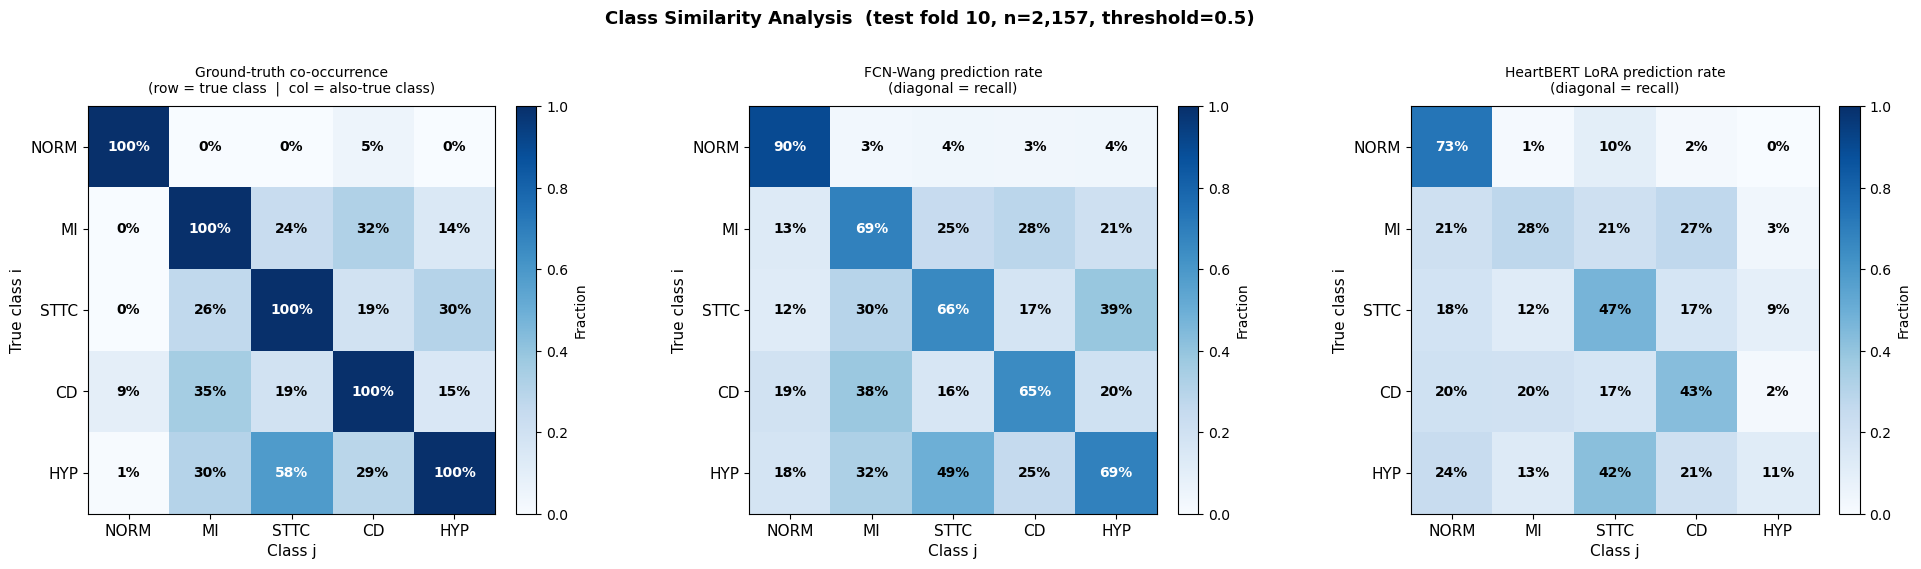

Saved -> D:\GitHub\biosignal-xai\results\05+_model_comparison\figures\class_similarity.png

Class   FCN recall   HB recall       FCN top co-pred        HB top co-pred
---------------------------------------------------------------------------
NORM         89.5%       73.3%              HYP (4%)            STTC (10%)
MI           68.5%       27.6%              CD (28%)              CD (27%)
STTC         65.8%       47.2%             HYP (39%)            NORM (18%)
CD           64.9%       43.1%              MI (38%)            NORM (20%)
HYP          68.7%       11.5%            STTC (49%)            STTC (42%)


In [19]:
n = len(SUPERCLASSES)

# ── Build co-occurrence matrices ──────────────────────────────────────────────

def _cooc_pred(preds, labels):
    """For each true class i, fraction of those records where model predicts class j.
    Diagonal = recall. Off-diagonal = co-predicted alongside each true class."""
    mat = np.zeros((n, n))
    for i in range(n):
        mask = labels[:, i] == 1
        if mask.sum() > 0:
            mat[i] = preds[mask].mean(axis=0)
    return mat

# Ground-truth: same for both models (it's the test set labels)
cooc_true = np.zeros((n, n))
for i in range(n):
    mask = fcn_labels_full[:, i] == 1
    if mask.sum() > 0:
        cooc_true[i] = fcn_labels_full[mask].mean(axis=0)

cooc_fcn = _cooc_pred(fcn_preds_full, fcn_labels_full)
cooc_hb  = _cooc_pred(hb_preds,       fcn_labels_full)   # same true labels

# ── Plot: 3 panels side by side ───────────────────────────────────────────────
fig_sim, axes = plt.subplots(1, 3, figsize=(20, 5.5))

panels = [
    (cooc_true, 'Ground-truth co-occurrence\n(row = true class  |  col = also-true class)'),
    (cooc_fcn,  'FCN-Wang prediction rate\n(diagonal = recall)'),
    (cooc_hb,   'HeartBERT LoRA prediction rate\n(diagonal = recall)'),
]

for ax, (mat, title) in zip(axes, panels):
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Fraction')
    ax.set_xticks(range(n));  ax.set_xticklabels(SUPERCLASSES, fontsize=11)
    ax.set_yticks(range(n));  ax.set_yticklabels(SUPERCLASSES, fontsize=11)
    ax.set_xlabel('Class j', fontsize=11)
    ax.set_ylabel('True class i', fontsize=11)
    ax.set_title(title, fontsize=10, pad=10)
    for i in range(n):
        for j in range(n):
            v = mat[i, j]
            ax.text(j, i, f'{v:.0%}', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if v > 0.55 else 'black')

plt.suptitle(
    f'Class Similarity Analysis  (test fold 10, n=2,157, threshold={CFG["inference"]["threshold"]})',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
fig_sim.savefig(FIG_DIR / 'class_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR / "class_similarity.png"}')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"Class":<6}  {"FCN recall":>10}  {"HB recall":>10}  '
      f'{"FCN top co-pred":>20}  {"HB top co-pred":>20}')
print('-' * 75)
for i, sc in enumerate(SUPERCLASSES):
    def _top(mat, i):
        tmp = mat[i].copy();  tmp[i] = -1
        j = int(np.argmax(tmp))
        return f'{SUPERCLASSES[j]} ({mat[i,j]:.0%})'
    print(f'{sc:<6}  {cooc_fcn[i,i]:>10.1%}  {cooc_hb[i,i]:>10.1%}  '
          f'{_top(cooc_fcn,i):>20}  {_top(cooc_hb,i):>20}')